## Usage of TMM script

___

Let us look at an example wherein two thin layers of refractive index n=1.5 and n=2.5 are placed above a cSi substrate. The layer stack for the simulation is:

### Air | n = 1.5 | n = 2.5 | c-Si 

The illumination has a `TE` polarization and is incident normally from the air side ($\theta=0\degree$). The goal is to measure the reflectance, absorption and transmittance of such a system.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from TMM import run_tmm

1) Load the dispersion of the cSi. This is provided to you in the file `cSi_dispersion_green08.csv`

In [2]:
csi = np.loadtxt('cSi_dispersion_green08.csv') # ordered as (wvl, n, k)
ncsi = csi[:,1] + 1j*csi[:,2]
wavelength_array = csi[:,0]

2. Create the two thin-layes. Let's choose the thicknesses of $n_1=1.5$ and $n_2=2.5$ layers to be $d_1=0.25 \mu\text{m}$  and $d_2=0.35\mu\text{m}$, respectively. 

In [ ]:
n_layers = np.array([1.5, 2.5])
d_layers = np.array([0.25, 0.35]) # ordered as air | d1 | d2 | substrate

In [40]:
r,t = run_tmm(d_list=d_layers, 
              n_list= n_layers,
              n_substrate = ncsi, 
              n_superstrate = 1, # air
              wavelength=wavelength_array)

Since the transmittance is always evaluated in a non-absorbing media, interally, the function creates a $10\mu\text{m}$ thick cSi layer and the substrate becomes the non-absorbing cSi infinite layer. This works out fine for cSi because at short wavelengths, most of the light is absorbed in the first few micrometers (skin-depth of cSi) and for long wavelength, the absorption coefficient is anyway very small. 

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2085791/257807030.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Wavelength ($\mathrm{\mu}$m)',fontsize=13)


Text(0.5, 0, 'Wavelength ($\\mathrm{\\mu}$m)')

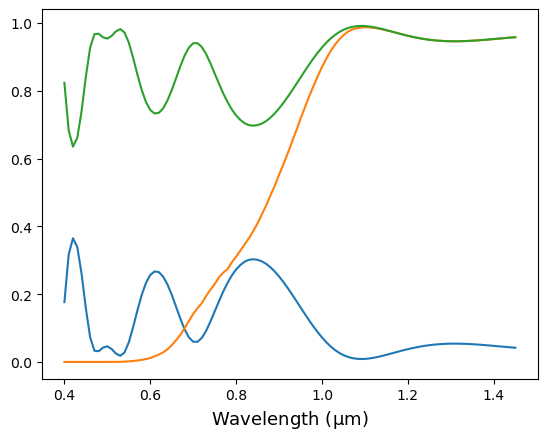

In [31]:
plt.plot(wavelength_array,r) # reflectance
plt.plot(wavelength_array,t) # transmittance : should be ideally zero in the infinite substrate thickness limit 
plt.plot(wavelength_array, 1 - r) # absorbance in the limit of infinite substrate thickness
plt.xlabel('Wavelength ($\mathrm{\mu}$m)',fontsize=13)

___

### Assuming the overall thickness is $d=d_1+d_2 = 0.6 \mu\text{m}$, create a quintic refractive index stack of 50-100 layers such that the reflectance shown above is dramatically minimized. Use $n_{min} = 1$ and $n_{max}=3.5$ for the quintic profile. Report your findings.